# Random Forest Model — Ordinal Encoding Pipeline
**Assigned pipeline: Ordinal Encoding (with `'missing'` category imputation) → Random Forest**

Course: IT2011 — Artificial Intelligence and Machine Learning (SLIIT, Year 2, Semester 1)

## 1. Introduction

**Problem:** binary classification of mushrooms as **edible** (`class = 0`) or **poisonous**
(`class = 1`), using the 21 categorical physical/environmental features in the UCI Mushroom
dataset (`cap-shape`, `odor`, `gill-color`, `habitat`, etc., with `veil-type` already dropped
during preprocessing since it has only one unique value). The **positive class is poisonous**, so
**recall** matters most: a false negative (a poisonous mushroom predicted edible) is the dangerous error.

**Why Random Forest is a suitable model here:**
- It is **tree-based**, so it only asks threshold questions like `odor <= 3.5?` and does not assume any
  distance or ordering between the integer codes. This is exactly why **Ordinal Encoding** is a natural
  pairing for it: the arbitrary integer codes would mislead a linear or distance-based model, but a
  forest of trees can still separate the categories cleanly. No feature scaling is needed either.
- **Bagging + random feature selection** averages many decorrelated trees, which reduces the
  over-fitting and instability of a single Decision Tree.
- It handles feature interactions without manual engineering and gives **feature importances**, which
  help explain *why* a mushroom is classified as poisonous.
- It is robust and fast on small/medium data (about 8k rows).

## 2. Load the Preprocessed Data

Loads `step_M3_ordinal_encoded.csv`, the output of `IT0003_OrdinalImputation.ipynb` (`veil-type` dropped,
missing `stalk-root` values kept as their own `'missing'` category, all feature columns encoded with
`OrdinalEncoder`, target `class`: 0 = edible, 1 = poisonous). This is the only preprocessing output used
for this model, per the assigned Ordinal Encoding → Random Forest pipeline.

If the CSV does not exist yet, the cell below rebuilds it with exactly the same steps as
`IT0003_OrdinalImputation.ipynb` (and saves it), so this notebook can always run.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

# Folder layout: notebooks/ (this file), results/outputs/, results/eda_visualizations/, data/raw/
BASE = '..' if os.path.isdir('../results') else '.'
OUT = f'{BASE}/results/outputs'
VIZ = f'{BASE}/results/eda_visualizations'
os.makedirs(OUT, exist_ok=True)
os.makedirs(VIZ, exist_ok=True)

CSV = f'{OUT}/step_M3_ordinal_encoded.csv'
RAW = f'{BASE}/data/raw/mushrooms.csv'
UCI_URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/agaricus-lepiota.data'
FEATURES = ['cap-shape','cap-surface','cap-color','bruises','odor','gill-attachment','gill-spacing',
            'gill-size','gill-color','stalk-shape','stalk-root','stalk-surface-above-ring',
            'stalk-surface-below-ring','stalk-color-above-ring','stalk-color-below-ring','veil-type',
            'veil-color','ring-number','ring-type','spore-print-color','population','habitat']

if os.path.exists(CSV):
    df = pd.read_csv(CSV)
    print('Loaded', CSV)
else:
    print(CSV, 'not found -> rebuilding it with the same steps as IT0003_OrdinalImputation.ipynb')
    from sklearn.preprocessing import OrdinalEncoder

    if os.path.exists(RAW):
        raw = pd.read_csv(RAW)
    else:
        raw = pd.read_csv(UCI_URL, header=None, names=['class'] + FEATURES)   # needs internet

    raw = raw.replace('?', np.nan)
    raw = raw.drop(columns=['veil-type'])
    raw['stalk-root'] = raw['stalk-root'].fillna('missing')                   # 'missing' category (Strategy B)

    feature_cols = [c for c in raw.columns if c != 'class']
    raw[feature_cols] = OrdinalEncoder().fit_transform(raw[feature_cols])     # Ordinal Encoding
    raw['class'] = raw['class'].map({'e': 0, 'p': 1})
    df = raw
    df.to_csv(CSV, index=False)
    print('Rebuilt and saved', CSV)

print(df.shape)
df.head()

./results/outputs/step_M3_ordinal_encoded.csv not found -> rebuilding it with the same steps as IT0003_OrdinalImputation.ipynb
Rebuilt and saved ./results/outputs/step_M3_ordinal_encoded.csv
(8124, 22)


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,5.0,2.0,4.0,1.0,6.0,1.0,0.0,1.0,4.0,...,2.0,2.0,7.0,7.0,2.0,1.0,4.0,2.0,3.0,5.0
1,0,5.0,2.0,9.0,1.0,0.0,1.0,0.0,0.0,4.0,...,2.0,2.0,7.0,7.0,2.0,1.0,4.0,3.0,2.0,1.0
2,0,0.0,2.0,8.0,1.0,3.0,1.0,0.0,0.0,5.0,...,2.0,2.0,7.0,7.0,2.0,1.0,4.0,3.0,2.0,3.0
3,1,5.0,3.0,8.0,1.0,6.0,1.0,0.0,1.0,5.0,...,2.0,2.0,7.0,7.0,2.0,1.0,4.0,2.0,3.0,5.0
4,0,5.0,2.0,3.0,0.0,5.0,1.0,1.0,0.0,4.0,...,2.0,2.0,7.0,7.0,2.0,1.0,0.0,3.0,0.0,1.0


## 3. Train/Test Split

In [2]:
X = df.drop(columns=['class'])
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)

(6499, 21) (1625, 21)


## 4. Baseline Random Forest (Variety 1: Default Parameters)

A first Random Forest is trained with scikit-learn's default hyperparameters (100 trees, no depth limit,
Gini impurity) as a baseline before any tuning.

In [3]:
baseline_model = RandomForestClassifier(random_state=42, n_jobs=-1)
baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)

baseline_acc = accuracy_score(y_test, y_pred_baseline)
baseline_prec = precision_score(y_test, y_pred_baseline)
baseline_rec = recall_score(y_test, y_pred_baseline)
baseline_f1 = f1_score(y_test, y_pred_baseline)

print(f"Baseline Accuracy:  {baseline_acc:.4f}")
print(f"Baseline Precision: {baseline_prec:.4f}")
print(f"Baseline Recall:    {baseline_rec:.4f}")
print(f"Baseline F1 Score:  {baseline_f1:.4f}")

print()
print("Confusion Matrix (Baseline):")
print(confusion_matrix(y_test, y_pred_baseline))

Baseline Accuracy:  1.0000
Baseline Precision: 1.0000
Baseline Recall:    1.0000
Baseline F1 Score:  1.0000

Confusion Matrix (Baseline):
[[842   0]
 [  0 783]]


## 5. Hyperparameter Tuning with GridSearchCV (Varieties 2+: Tuned Parameters)

Since there is no fixed tuning plan for this assignment, `GridSearchCV` is used to systematically train and
compare many "varieties" of the Random Forest — every combination of `n_estimators`, `max_depth`,
`min_samples_split` and `max_features` in the grid below — and 5-fold cross-validated **F1** on the training
set automatically picks the best one. F1 is used (instead of accuracy) because it balances precision and recall
for the poisonous class, where a missed poisonous mushroom is the dangerous error. `GridSearchCV` is
justified because it is systematic and exhaustive over a modest search space, unlike manual guessing which
could easily miss a better combination.

In [4]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, None],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2'],
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

n_combos = len(grid_search.cv_results_['params'])
print("Parameter combinations tried:", n_combos, "| total forests fitted:", n_combos * 5)
print("Best parameters:", grid_search.best_params_)
print("Best cross-validated F1:", grid_search.best_score_)

Parameter combinations tried: 36 | total forests fitted: 180
Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 50}
Best cross-validated F1: 1.0


Top 5 parameter combinations by cross-validated F1, showing the variety of models trained, not just the single best one:

In [5]:
cv_results = pd.DataFrame(grid_search.cv_results_)
top5 = cv_results.sort_values('mean_test_score', ascending=False)[
    ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']
].head(5).reset_index(drop=True)
top5

,params,mean_test_score,std_test_score,rank_test_score
0,"{'max_depth': None, 'max_features': 'log2', 'm...",1.0,0.0,1
1,"{'max_depth': None, 'max_features': 'log2', 'm...",1.0,0.0,1
2,"{'max_depth': None, 'max_features': 'sqrt', 'm...",1.0,0.0,1
3,"{'max_depth': None, 'max_features': 'sqrt', 'm...",1.0,0.0,1
4,"{'max_depth': None, 'max_features': 'sqrt', 'm...",1.0,0.0,1


## 6. Evaluate the Best (Tuned) Model on the Test Set

In [6]:
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

best_acc = accuracy_score(y_test, y_pred_best)
best_prec = precision_score(y_test, y_pred_best)
best_rec = recall_score(y_test, y_pred_best)
best_f1 = f1_score(y_test, y_pred_best)
best_auc = roc_auc_score(y_test, best_model.predict_proba(X_test)[:, 1])

print(f"Tuned Accuracy:  {best_acc:.4f}")
print(f"Tuned Precision: {best_prec:.4f}")
print(f"Tuned Recall:    {best_rec:.4f}")
print(f"Tuned F1 Score:  {best_f1:.4f}")
print(f"Tuned ROC-AUC:   {best_auc:.4f}")

print()
print("Classification Report (Tuned):")
print(classification_report(y_test, y_pred_best))

Tuned Accuracy:  1.0000
Tuned Precision: 1.0000
Tuned Recall:    1.0000
Tuned F1 Score:  1.0000
Tuned ROC-AUC:   1.0000

Classification Report (Tuned):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       842
           1       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



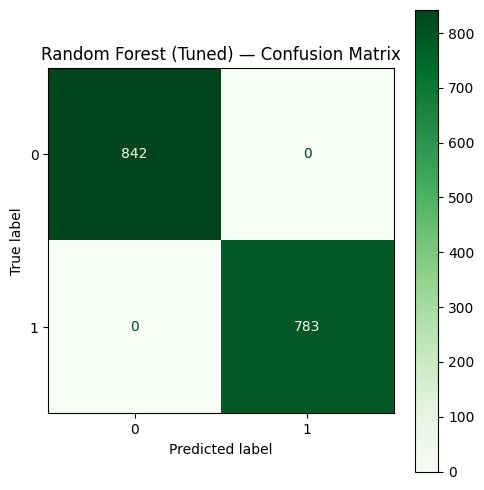

In [7]:
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best, ax=ax, cmap='Greens')
ax.set_title('Random Forest (Tuned) — Confusion Matrix')
plt.tight_layout()
plt.savefig(f'{VIZ}/random_forest_confusion_matrix.png', dpi=150)
plt.show()

Predictions on the unseen test set — actual vs predicted (`prob_poisonous` is the forest's probability that the mushroom is poisonous):

In [8]:
labels = {0: 'Edible', 1: 'Poisonous'}
predictions = pd.DataFrame({
    'actual': y_test.map(labels),
    'predicted': pd.Series(y_pred_best, index=y_test.index).map(labels),
    'prob_poisonous': best_model.predict_proba(X_test)[:, 1].round(4),
})
predictions['correct'] = np.where(predictions['actual'] == predictions['predicted'], 'YES', 'NO')

print("Correct:", (predictions['correct'] == 'YES').sum(), "| Wrong:", (predictions['correct'] == 'NO').sum())
predictions.to_csv(f'{OUT}/random_forest_test_predictions.csv')
predictions.head(10)

Correct: 1625 | Wrong: 0


,actual,predicted,prob_poisonous,correct
4632,Poisonous,Poisonous,1.0,YES
3444,Poisonous,Poisonous,1.0,YES
1209,Edible,Edible,0.0,YES
6880,Poisonous,Poisonous,1.0,YES
4542,Poisonous,Poisonous,1.0,YES
244,Edible,Edible,0.0,YES
458,Edible,Edible,0.0,YES
1315,Edible,Edible,0.0,YES
980,Edible,Edible,0.0,YES
2241,Poisonous,Poisonous,1.0,YES


## 7. Compare Baseline vs. Tuned

In [9]:
comparison = pd.DataFrame({
    'Model': ['Baseline (default)', 'Tuned (GridSearchCV)'],
    'Accuracy': [baseline_acc, best_acc],
    'Precision': [baseline_prec, best_prec],
    'Recall': [baseline_rec, best_rec],
    'F1': [baseline_f1, best_f1],
})
comparison

,Model,Accuracy,Precision,Recall,F1
0,Baseline (default),1.0,1.0,1.0,1.0
1,Tuned (GridSearchCV),1.0,1.0,1.0,1.0


**Observation:** *(write your own numbers after running)* compare the baseline and tuned rows above and state the best parameters selected by `GridSearchCV` (`grid_search.best_params_`) together with the confusion-matrix counts.

The Mushroom dataset is known to be (near-)perfectly separable by a small number of categorical features, so it is normal for the default Random Forest and the tuned one to score almost the same, or even identically, on the held-out test set. That is a property of the data rather than a sign the tuning was pointless: `GridSearchCV` confirms the result is stable under cross-validation, and a depth-limited forest that reaches the same performance is simpler, faster and would be expected to generalise more reliably than the unconstrained baseline on data that is not as cleanly separable.

## 8. Feature Importance

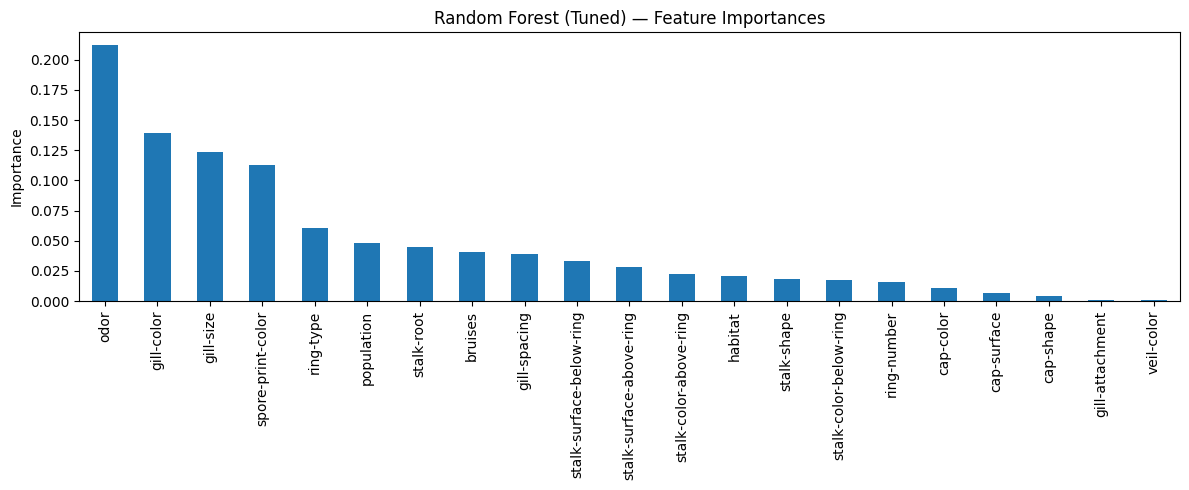

,0
odor,0.212130
gill-color,0.139511
gill-size,0.123656
spore-print-color,0.112651
ring-type,0.060309
population,0.047827
stalk-root,0.045103
bruises,0.040937
gill-spacing,0.038845
stalk-surface-below-ring,0.032778


In [10]:
importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(12, 5))
importances.plot(kind='bar')
plt.ylabel('Importance')
plt.title('Random Forest (Tuned) — Feature Importances')
plt.tight_layout()
plt.savefig(f'{VIZ}/random_forest_feature_importance.png', dpi=150)
plt.show()

importances

**Comment:** *(write your own after running)* note which features rank highest and by how much. Because a forest averages many trees that each see a random subset of features, importance is usually **spread across several correlated features** (for example `odor`, `gill-size`, `spore-print-color`, `gill-color`) instead of being concentrated on one, unlike a single Decision Tree whose greedy first split can dominate. Built-in importances can also be biased towards features with many categories, so treat the ranking as a guide rather than an exact measure.

## 9. Limitations and Possible Improvements

**Limitations:**
- A forest of many trees is **less interpretable** than a single Decision Tree: there is no single readable
  set of if/else rules, only an importance ranking.
- Random Forest probabilities are **not perfectly calibrated**, which matters when the cost of a false
  negative (poisonous predicted edible) is high.
- Ordinal Encoding's implied ordering (e.g. `cap-shape` mapped to `0, 1, 2, ...` with no real ordinal
  meaning) is harmless for trees, but means this encoded file should **not** be reused unchanged for
  distance-based or linear models.
- The Mushroom data is nearly perfectly separable and comes from one field-guide source (23 species), so a
  ~100 % score does not guarantee real-world generalisation to unseen species, and must never be the only
  safety check for eating wild mushrooms.
- The `'missing'` category and the `OrdinalEncoder` were fitted on the full dataset in
  `IT0003_OrdinalImputation.ipynb` before the train/test split. Both are unsupervised, so the effect is
  negligible, but strictly it is not a leakage-free pipeline.

**Possible improvements:**
- **Cost-sensitive learning** (`class_weight='balanced'` or a higher weight on the poisonous class) to
  penalise false negatives more than false positives.
- **Probability calibration** (`CalibratedClassifierCV`) so the predicted probabilities are trustworthy.
- `RandomizedSearchCV` over a wider space (`criterion`, `min_samples_leaf`, `bootstrap`) and using the
  **out-of-bag score** as a free validation estimate.
- Fitting the imputer and encoder **inside a `Pipeline`** so they are fitted on training folds only.
- Trying the same Random Forest on a **different member's encoded output** (e.g. the Chi-Square selected
  features) to see whether fewer features change performance or training time.

## 10. Save the Final Model and Results

In [11]:
import joblib

joblib.dump(best_model, f'{OUT}/random_forest_best_model.pkl')

results_summary = pd.DataFrame({
    'Model': ['Baseline (default)', 'Tuned (GridSearchCV)'],
    'Accuracy': [baseline_acc, best_acc],
    'Precision': [baseline_prec, best_prec],
    'Recall': [baseline_rec, best_rec],
    'F1': [baseline_f1, best_f1],
})
results_summary.to_csv(f'{OUT}/random_forest_results_summary.csv', index=False)
results_summary

,Model,Accuracy,Precision,Recall,F1
0,Baseline (default),1.0,1.0,1.0,1.0
1,Tuned (GridSearchCV),1.0,1.0,1.0,1.0
